Making Data Structure and Loading Data either from mat files or cached files.

To see how the following code works and what is the meaning of the imported code such import src.utils.config as config read the tutorial.ipynb file




In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

# import local libraries
import src.utils.config as config
import proc.process_behavior_signals as pbs
# import proc.organize as org
import src.utils.data_io as dio
import src.utils.pdata_io as pdio
import numpy as np

# print(config.PROJECT_ROOT)
# print(config.RAW_BASE)
# print(config.PROC_BASE)

import sys
from pathlib import Path

CODE_BASE = Path(config.CODE_BASE).expanduser()
sys.path.append(str(CODE_BASE))

print("Added to path:", CODE_BASE)

# make the data dictionary which contains list of all animals and sessions and
# file names of videos h264 and mat files

data_root = config.RAW_BASE # this variable now contains the path to the raw data directory, which is defined in the config file. It is used to build the classical conditioning data dictionary using the dio.build_classical_conditioning_dict function. The resulting cc_data variable will contain the structured information about the animals, sessions, and file names for the classical conditioning experiments.
cc_data = dio.build_classical_conditioning_dict(data_root)

pdata_root = config.PROC_BASE # this variable now contains the path to the processed data directory, which is defined in the config file. It is used to build the processed data dictionary using the pdio.build_processed_data_dict function. The resulting pdata variable will contain the structured information about the animals, sessions, and file names for the processed data of the classical conditioning experiments.
print(data_root)
print(pdata_root)

/home/nmldata2/ccaw/Python
Added to path: /home/nmldata2/ccaw/Python
/mnt/data/Classical_Conditioning
/mnt/pdata/Classical_Conditioning


In [2]:
print(cc_data)
print(cc_data["NML_07"]["2026_03_11"])

{'NML_04': {'2025_12_27': {'face': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/face_1440x1080_60_20251227_154519.h264', 'pupi': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/pupi_320x240_60_20251227_154519.h264', 'video': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/video_20251227_154511.h264', 'recording': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/recording_20251227_154502.mat', 'phase': 'habituation', 'path': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27'}, '2025_12_28': {'face': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/face_1440x1080_60_20251228_154642.h264', 'pupi': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/pupi_320x240_60_20251228_154642.h264', 'video': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/video_20251228_154758.h264', 'recording': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/recording_20251228_154611.mat', 'phase': 'habituation', 'path': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28'}, '2025_12_2

# In the following code we will process the cc_data variable to analyze the mat files of recording to find speed of the animal from the encoder data

We will store it in h5 or hdf5 format

the phase value is given as 1) habituation, 2) air_training, and 3) tone_air_training



In [ ]:
results = pbs.process_cc_data(
    cc_data,
    # animals={"NML_04"},
    # phase="tone_air_training", # "habituation", "air_training", "tone_air_training"
    # dates={"2026_01_13"},
    # overwrite=True,
)

"""
Tutorial: Understanding the variables inside the behavior H5 file

After processing one behavioral session, the data are saved in an H5 file.
Each H5 file contains several variables that describe timing, air stimulus,
wheel movement, speed, and trial-by-trial behavior.
"""

# -----------------------------------------------------
# 1. Timing variables
# -----------------------------------------------------

"""
fs
    Sampling rate of the DAQ recording.
    Example: if fs = 5000, the system collected 5000 samples per second.

si
    Sampling interval.
    This is the time between two consecutive samples.

    si = 1 / fs

t
    Time vector in seconds.
    This gives the time point for every sample.

tm
    Time vector in minutes.

    tm = t / 60

number_of_samples
    Total number of samples in the recording.
"""

# -----------------------------------------------------
# 2. Air stimulus variables
# -----------------------------------------------------

"""
air_raw
    Raw air signal recorded from the DAQ.

air_bin
    Binary air signal.

    0 = air OFF
    1 = air ON

Air_r
    Air rising edges.
    These are the sample indices where air turns ON.

Air_f
    Air falling edges.
    These are the sample indices where air turns OFF.

Together:

    Air_r[i] = start of air trial i
    Air_f[i] = end of air trial i
"""

# -----------------------------------------------------
# 3. Encoder / wheel variables
# -----------------------------------------------------

"""
encoderCount
    Raw encoder count signal from the wheel.
    This represents wheel position over time.

countsPerRev
    Number of encoder counts in one full wheel revolution.
    This is used to convert encoder counts into distance.
"""

# -----------------------------------------------------
# 4. Distance variables
# -----------------------------------------------------

"""
dist_net_cm
    Net distance in centimeters.
    This keeps direction.

    Forward movement increases the value.
    Backward movement can decrease the value.

dist_path_cm
    Total path distance in centimeters.
    This ignores direction.

    Forward movement increases the value.
    Backward movement also increases the value.

Simple explanation:

    dist_net_cm  = final position relative to start
    dist_path_cm = total amount of movement
"""

# -----------------------------------------------------
# 5. Speed variables
# -----------------------------------------------------

"""
speed_net_cms
    Net speed in cm/s.
    This keeps direction.

    Positive values = movement in one direction
    Negative values = movement in the opposite direction

speed_path_cms
    Path speed in cm/s.
    This ignores direction.

    It tells us how fast the animal is moving overall.

speed_window_ms
    Window size used to calculate speed.
    In this pipeline, speed is calculated using a 100 ms window.
"""

# -----------------------------------------------------
# 6. Trial-level variable
# -----------------------------------------------------

"""
trial_forward_cm
    Forward distance traveled during each air trial.

    trial_forward_cm[0] = forward distance during trial 1
    trial_forward_cm[1] = forward distance during trial 2
    trial_forward_cm[2] = forward distance during trial 3

This is useful for checking whether the animal ran enough during each air trial.
"""

# -----------------------------------------------------
# 7. Most useful variables for analysis
# -----------------------------------------------------

"""
For general locomotion analysis:

    t
    speed_path_cms
    dist_path_cm

For air trial analysis:

    Air_r
    Air_f
    air_bin
    trial_forward_cm

For synchronization and raw signal inspection:

    air_raw
    encoderCount

For time conversion:

    fs
    si
    t
    tm
"""

# -----------------------------------------------------
# 8. Simple interpretation
# -----------------------------------------------------

"""
In simple words:

The H5 file stores the processed behavior for one animal on one recording day.

It tells us:

    when the recording happened in time,
    when air turned on and off,
    how the wheel moved,
    how fast the animal moved,
    how far the animal moved,
    and how much the animal ran during each air trial.

This makes the H5 file the main processed behavior file for later analysis.
"""

In [7]:
animal = "NML_04"
date = "2026_01_05"
h5_file = pdio.behavior_h5_path(animal, date)
print(h5_file)

/mnt/pdata/Classical_Conditioning/NML_04/2026_01_05/behavior/behavior_v1.h5


In [8]:
keys = pdio.list_behavior_h5_keys(animal, date)
print(keys)

['Air_f', 'Air_r', 'air_bin', 'air_raw', 'bias', 'countsPerRev', 'dist_net_cm', 'dist_path_cm', 'encoderCount', 'fs', 'number_of_samples', 'si', 'speed_net_cms', 'speed_path_cms', 'speed_window_ms', 't', 'tm', 'trial_forward_cm']


In [ ]:
# Load full behavior file
b = pdio.load_behavior_h5(animal, date)
b.keys()

In [12]:
# Load selected keys (variable) from behavior file.
speed_path_cm = pdio.load_behavior_h5(
    animal,
    date,
    keys="speed_path_cms"
)

speed_path_cm

{'speed_path_cms': array([0., 0., 0., ..., 0., 0., 0.])}

The following is the code to generate summaries of the records of what is available in the data folders

Below I am going to start actual processing of the data, looking at different aspects of speed and its relationship with habituation phase, air-training phase


In [25]:
import proc.behavior_metrics as bm

hab_state_1cms = bm.summarize_habituation_locomotor_states(
    resultsH,
    speed_thresh=1.0
)

# hab_state_1cms.head()


,animal,date,phase,speed_thresh,habituation_session,n_habituation_sessions,normalized_day,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,mean_path_speed,median_path_speed,mean_net_speed,median_net_speed,total_path_distance_cm,net_distance_cm
0,NML_04,2025_12_27,Habituation,1.0,1,16,0.000000,0.755568,0.244432,0.136168,0.108264,0.0,0.783014,0.0,0.121107,0.0,1054.343627,158.813792
1,NML_04,2025_12_28,Habituation,1.0,2,16,0.066667,0.800637,0.199363,0.112474,0.086889,0.0,0.592844,0.0,0.068305,0.0,899.500809,100.581230
2,NML_04,2025_12_29,Habituation,1.0,3,16,0.133333,0.760377,0.239623,0.180129,0.059494,0.0,0.706021,0.0,0.386026,0.0,906.839569,484.257658
3,NML_04,2025_12_30,Habituation,1.0,4,16,0.200000,0.738072,0.261928,0.223719,0.038209,0.0,0.910905,0.0,0.716319,0.0,1498.011908,1163.444857
4,NML_04,2025_12_31,Habituation,1.0,5,16,0.266667,0.765979,0.234021,0.211168,0.022853,0.0,0.859619,0.0,0.713525,0.0,1152.989637,946.549300


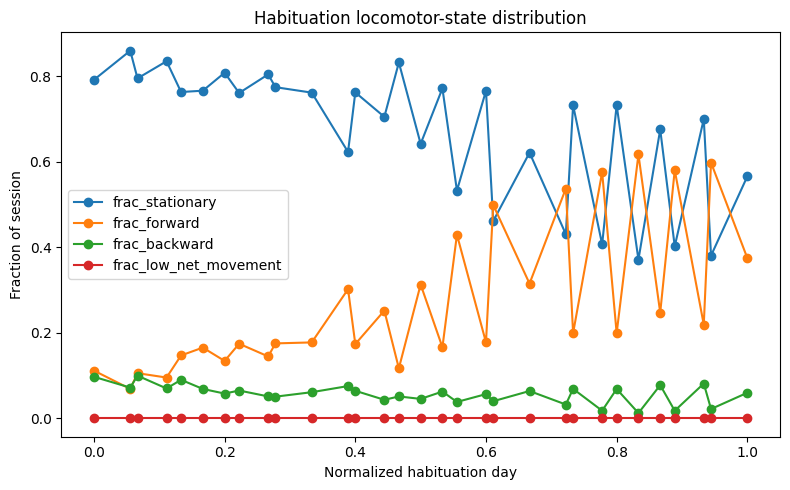

In [32]:
import matplotlib.pyplot as plt

state_cols = [
    "frac_stationary",
    "frac_forward",
    "frac_backward",
    "frac_low_net_movement"
]

df = hab_state_1cms.copy()

mean_by_day = (
    df.groupby("normalized_day")[state_cols]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

for col in state_cols:
    plt.plot(mean_by_day["normalized_day"], mean_by_day[col], marker="o", label=col)

plt.xlabel("Normalized habituation day")
plt.ylabel("Fraction of session")
plt.title("Habituation locomotor-state distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
import statsmodels.formula.api as smf


def logit_clip(p, eps=1e-4):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


df = hab_state_1cms.copy()

df["logit_frac_moving"] = logit_clip(df["frac_moving"])
df["logit_frac_forward"] = logit_clip(df["frac_forward"])
df["logit_frac_backward"] = logit_clip(df["frac_backward"])
df["logit_frac_stationary"] = logit_clip(df["frac_stationary"])


model_moving = smf.mixedlm(
    "logit_frac_moving ~ normalized_day",
    data=df,
    groups=df["animal"]
)

result_moving = model_moving.fit()
print(result_moving.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logit_frac_moving
No. Observations: 86      Method:             REML             
No. Groups:       5       Scale:              1.1585           
Min. group size:  16      Log-Likelihood:     -135.1757        
Max. group size:  19      Converged:          Yes              
Mean group size:  17.2                                         
----------------------------------------------------------------
                 Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------
Intercept        -1.901     0.625  -3.041  0.002  -3.127  -0.676
normalized_day    2.249     0.379   5.929  0.000   1.506   2.992
Group Var         1.708     1.192                               



In [34]:
model_forward = smf.mixedlm(
    "logit_frac_forward ~ normalized_day",
    data=df,
    groups=df["animal"]
)

result_forward = model_forward.fit()
print(result_forward.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logit_frac_forward
No. Observations: 86      Method:             REML              
No. Groups:       5       Scale:              0.9076            
Min. group size:  16      Log-Likelihood:     -125.3347         
Max. group size:  19      Converged:          Yes               
Mean group size:  17.2                                          
-----------------------------------------------------------------
                  Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------------
Intercept         -2.524     0.608  -4.151  0.000  -3.715  -1.332
normalized_day     2.391     0.336   7.122  0.000   1.733   3.049
Group Var          1.654     1.296                               



In [35]:
model_backward = smf.mixedlm(
    "logit_frac_backward ~ normalized_day",
    data=df,
    groups=df["animal"]
)

result_backward = model_backward.fit()
print(result_backward.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logit_frac_backward
No. Observations: 86      Method:             REML               
No. Groups:       5       Scale:              0.2084             
Min. group size:  16      Log-Likelihood:     -61.4469           
Max. group size:  19      Converged:          Yes                
Mean group size:  17.2                                           
------------------------------------------------------------------
                  Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept         -2.454     0.185  -13.293  0.000  -2.816  -2.092
normalized_day    -0.792     0.161   -4.923  0.000  -1.107  -0.477
Group Var          0.126     0.219                                



In [31]:
import proc.behavior_metrics as bm

hab_state_0p5cms = bm.summarize_habituation_locomotor_states(
    resultsH,
    speed_thresh=0.5
)

hab_state_0p5cms.head()

NameError: name 'hab_state_0p5cms' is not defined

In [36]:
import proc.behavior_metrics as bm

hab_state_1p5cms = bm.summarize_habituation_locomotor_states(
    resultsH,
    speed_thresh=1.5
)

hab_state_1p5cms.head()

,animal,date,phase,speed_thresh,habituation_session,n_habituation_sessions,normalized_day,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,mean_path_speed,median_path_speed,mean_net_speed,median_net_speed,total_path_distance_cm,net_distance_cm
0,NML_04,2025_12_27,Habituation,1.5,1,16,0.000000,0.815026,0.184974,0.104761,0.080213,0.0,0.783014,0.0,0.121107,0.0,1054.343627,158.813792
1,NML_04,2025_12_28,Habituation,1.5,2,16,0.066667,0.862089,0.137911,0.077862,0.060049,0.0,0.592844,0.0,0.068305,0.0,899.500809,100.581230
2,NML_04,2025_12_29,Habituation,1.5,3,16,0.133333,0.827939,0.172061,0.136276,0.035785,0.0,0.706021,0.0,0.386026,0.0,906.839569,484.257658
3,NML_04,2025_12_30,Habituation,1.5,4,16,0.200000,0.788626,0.211374,0.188903,0.022471,0.0,0.910905,0.0,0.716319,0.0,1498.011908,1163.444857
4,NML_04,2025_12_31,Habituation,1.5,5,16,0.266667,0.807191,0.192809,0.179732,0.013076,0.0,0.859619,0.0,0.713525,0.0,1152.989637,946.549300


/home/nmldata2/ccaw/Python/vis/plots.py:95: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


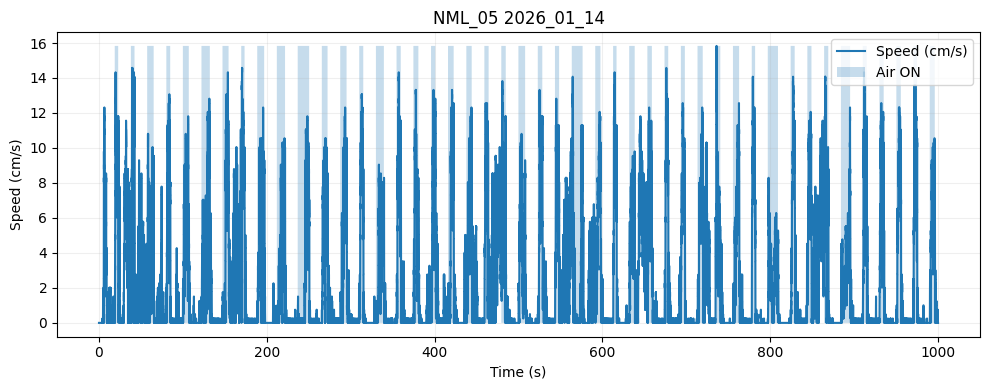

In [47]:
from vis.plots import quick_plot

quick_plot(results, "NML_05", "2026_01_14", tlim=(0,1000))